In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Selected Topics: Vital Signs Deep Learning Classification Pipeline
==================================================================
Input  : Heart Rate | SpO2 | Temperature
Output : Normal (0)  |  Abnormal (1)  |  Critical (2)
"""

import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc as skl_auc,
)

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_OK = True
except ImportError:
    SMOTE_OK = False
    print("[WARN] imbalanced-learn not installed - skipping SMOTE")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

try:
    from thop import profile as thop_profile
    THOP_OK = True
except ImportError:
    THOP_OK = False
    print("[WARN] thop not installed - using manual FLOPs")

# ─── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR   = os.getcwd()                              # works in Jupyter
DATA_DIR   = os.path.join(BASE_DIR, "..", "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── Settings ─────────────────────────────────────────────────────────────────
VITAL_FEATURES    = ["heart_rate", "spo2", "temperature"]
TARGET            = "risk_level"
CLASS_NAMES       = ["Normal", "Abnormal", "Critical"]
N_CLASSES         = 3

SEED              = 42
EPOCHS            = 25
BATCH_SIZE        = 2048
LR                = 3e-3
PATIENCE          = 15
SMOTE_CAP         = 15_000   # samples per class fed to SMOTE

CPU_WATTS         = 65
GPU_WATTS         = 0
CARBON_KG_PER_KWH = 0.233

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Log helper ───────────────────────────────────────────────────────────────
_LOG = []
def log(msg=""):
    print(msg)
    _LOG.append(str(msg))

def hdr(title):
    log(f"\n{'='*65}")
    log(f"  {title}")
    log("="*65)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Data dir: {DATA_DIR}")

Device  : cpu
PyTorch : 2.7.1+cpu
Data dir: c:\Users\HP\Downloads\AI XGBoost V3\AI XGBoost V3\selected topics\..\data


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 -- DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
hdr("STEP 1 -- DATA LOADING")

train_df = pd.read_excel(os.path.join(DATA_DIR, "vital_signs_train.xlsx"))
val_df   = pd.read_excel(os.path.join(DATA_DIR, "vital_signs_val.xlsx"))
test_df  = pd.read_excel(os.path.join(DATA_DIR, "vital_signs_test.xlsx"))

log(f"  Train : {train_df.shape}   Val : {val_df.shape}   Test : {test_df.shape}")
log(f"\n  Label distribution (train):")
for lbl, cnt in train_df[TARGET].value_counts().sort_index().items():
    log(f"    Class {lbl} ({CLASS_NAMES[int(lbl)]}) : {cnt:>6} samples")


  STEP 1 -- DATA LOADING
  Train : (119154, 7)   Val : (25533, 7)   Test : (25533, 7)

  Label distribution (train):
    Class 0 (Normal) :  37943 samples
    Class 1 (Abnormal) :  40605 samples
    Class 2 (Critical) :  40606 samples



  STEP 2 -- DATA PREPROCESSING

  [2a] Outlier Removal -- IQR method (factor = 2.0)
     Before: 119154  After: 91244  Removed: 27910 (23.4%)
     Class 0 (Normal) :  37943 samples
     Class 1 (Abnormal) :  40605 samples
     Class 2 (Critical) :  12696 samples


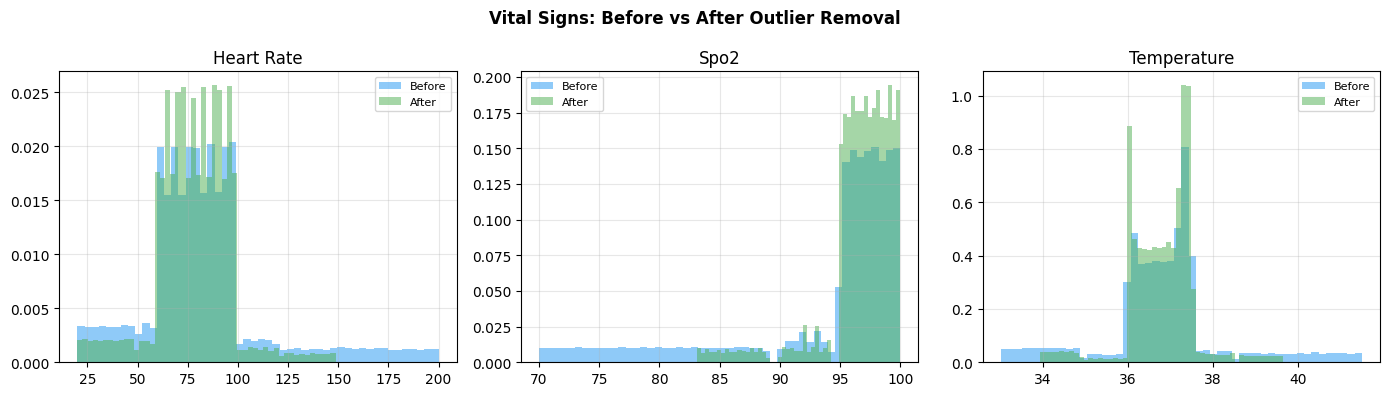


  [2b] Feature Scaling -- StandardScaler
     Mean : [78.396 96.684 36.809]
     Std  : [18.578  3.024  0.802]

  [2c] Data Augmentation -- Gaussian Noise + SMOTE
     Gaussian noise  : 91244 -> 182488 samples
     SMOTE input     : 45000 samples (15000/class)
     After SMOTE     : 227488 samples   {np.int64(0): 90886, np.int64(1): 96210, np.int64(2): 40392}

     Train: (227488, 3)  Val: (25533, 3)  Test: (25533, 3)


In [12]:
# ─── STEP 2 -- DATA PREPROCESSING ────────────────────────────────────────────
hdr("STEP 2 -- DATA PREPROCESSING")

# 2a. Outlier Removal (IQR, factor=2.0)
log("\n  [2a] Outlier Removal -- IQR method (factor = 2.0)")

def remove_outliers_iqr(df, cols, factor=2.0):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        mask &= df[col].between(q1 - factor*iqr, q3 + factor*iqr)
    return df[mask].copy()

n_before    = len(train_df)
train_clean = remove_outliers_iqr(train_df, VITAL_FEATURES)
n_after     = len(train_clean)
log(f"     Before: {n_before}  After: {n_after}  Removed: {n_before-n_after} ({(n_before-n_after)/n_before*100:.1f}%)")
for lbl, cnt in train_clean[TARGET].value_counts().sort_index().items():
    log(f"     Class {lbl} ({CLASS_NAMES[int(lbl)]}) : {cnt:>6} samples")

# Distribution plot (before vs after)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Vital Signs: Before vs After Outlier Removal", fontweight="bold")
for col, ax in zip(VITAL_FEATURES, axes):
    ax.hist(train_df[col], bins=50, alpha=0.5, label="Before", color="#2196F3", density=True)
    ax.hist(train_clean[col], bins=50, alpha=0.5, label="After", color="#4CAF50", density=True)
    ax.set_title(col.replace("_"," ").title()); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "00_data_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# 2b. Feature Scaling
log("\n  [2b] Feature Scaling -- StandardScaler")
scaler = StandardScaler()

X_tr_raw = train_clean[VITAL_FEATURES].values
y_tr_raw = train_clean[TARGET].values.astype(int)
X_va_raw = val_df[VITAL_FEATURES].values
y_va_raw = val_df[TARGET].values.astype(int)
X_te_raw = test_df[VITAL_FEATURES].values
y_te_raw = test_df[TARGET].values.astype(int)

X_tr = scaler.fit_transform(X_tr_raw)
X_va = scaler.transform(X_va_raw)
X_te = scaler.transform(X_te_raw)
log(f"     Mean : {scaler.mean_.round(3)}")
log(f"     Std  : {scaler.scale_.round(3)}")

# 2c. Augmentation: Gaussian Noise + SMOTE (capped per class for speed)
log("\n  [2c] Data Augmentation -- Gaussian Noise + SMOTE")

def add_noise(X, std=0.04):
    return X + np.random.normal(0, std, X.shape)

X_aug = np.vstack([X_tr, add_noise(X_tr)])
y_aug = np.concatenate([y_tr_raw, y_tr_raw])
log(f"     Gaussian noise  : {len(X_tr)} -> {len(X_aug)} samples")

if SMOTE_OK:
    try:
        idx = []
        for cls in range(N_CLASSES):
            cls_idx = np.where(y_aug == cls)[0]
            n_take  = min(len(cls_idx), SMOTE_CAP)
            idx.extend(np.random.choice(cls_idx, n_take, replace=False).tolist())
        idx = np.array(idx)
        X_sm_in, y_sm_in = X_aug[idx], y_aug[idx]
        log(f"     SMOTE input     : {len(X_sm_in)} samples ({SMOTE_CAP}/class)")

        smote = SMOTE(random_state=SEED)
        X_sm_out, y_sm_out = smote.fit_resample(X_sm_in, y_sm_in)
        X_aug = np.vstack([X_aug, X_sm_out])
        y_aug = np.concatenate([y_aug, y_sm_out])
        from collections import Counter
        log(f"     After SMOTE     : {len(X_aug)} samples   {dict(sorted(Counter(y_aug).items()))}")
    except Exception as e:
        log(f"     [WARN] SMOTE: {e}")

log(f"\n     Train: {X_aug.shape}  Val: {X_va.shape}  Test: {X_te.shape}")

In [13]:
# ─── STEP 3 -- DEEP LEARNING MODEL (Deep Residual MLP) ───────────────────────
hdr("STEP 3 -- DEEP LEARNING MODEL ARCHITECTURE")

class ResBlock(nn.Module):
    """Linear -> BN -> ReLU -> Dropout -> Linear -> BN  (+skip connection) -> ReLU"""
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.fc1  = nn.Linear(in_dim,  out_dim)
        self.bn1  = nn.BatchNorm1d(out_dim)
        self.fc2  = nn.Linear(out_dim, out_dim)
        self.bn2  = nn.BatchNorm1d(out_dim)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        skip = self.proj(x)
        x    = F.relu(self.bn1(self.fc1(x)))
        x    = self.drop(x)
        x    = self.bn2(self.fc2(x))
        return F.relu(x + skip)


class VitalSignsResNet(nn.Module):
    """
    Deep Residual MLP: 3 -> 128 -> 256 -> 512 -> 512 -> 256 -> 128 -> 64 -> 3
    6 residual blocks with skip connections, BatchNorm, and Dropout.
    """
    def __init__(self, n_in=3, n_cls=3):
        super().__init__()
        self.stem   = nn.Sequential(nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU())
        self.block1 = ResBlock(128, 256, dropout=0.30)
        self.block2 = ResBlock(256, 512, dropout=0.35)
        self.block3 = ResBlock(512, 512, dropout=0.35)
        self.block4 = ResBlock(512, 256, dropout=0.30)
        self.block5 = ResBlock(256, 128, dropout=0.25)
        self.block6 = ResBlock(128,  64, dropout=0.20)
        self.head   = nn.Sequential(nn.Dropout(0.20), nn.Linear(64, n_cls))

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.block4(x); x = self.block5(x); x = self.block6(x)
        return self.head(x)


model            = VitalSignsResNet(n_in=len(VITAL_FEATURES), n_cls=N_CLASSES).to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

log(f"  Architecture : Stem -> 6 x ResBlock -> Classifier Head")
log(f"  Parameters   : {total_params:,} total  |  {trainable_params:,} trainable")
log(f"  Device       : {DEVICE}")


  STEP 3 -- DEEP LEARNING MODEL ARCHITECTURE
  Architecture : Stem -> 6 x ResBlock -> Classifier Head
  Parameters   : 1,622,275 total  |  1,622,275 trainable
  Device       : cpu


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 -- TRAINING
# ─────────────────────────────────────────────────────────────────────────────
hdr("STEP 4 -- TRAINING")

def make_loader(X, y, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0,
    )

train_loader = make_loader(X_aug, y_aug)
val_loader   = make_loader(X_va, y_va_raw, shuffle=False)
test_loader  = make_loader(X_te, y_te_raw, shuffle=False)

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss, patience_count, best_state = float("inf"), 0, None

log(f"\n  Epochs={EPOCHS}  BatchSize={BATCH_SIZE}  LR={LR}  Patience={PATIENCE}")
log(f"  {'Epoch':>6}  {'Tr Loss':>9}  {'Tr Acc':>8}  {'Val Loss':>9}  {'Val Acc':>8}  {'LR':>10}")
log(f"  {'-'*65}")

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss    += loss.item() * len(yb)
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total   += len(yb)
    tr_loss /= tr_total
    tr_acc   = tr_correct / tr_total

    model.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(Xb)
            loss    = criterion(logits, yb)
            vl_loss    += loss.item() * len(yb)
            vl_correct += (logits.argmax(1) == yb).sum().item()
            vl_total   += len(yb)
    vl_loss /= vl_total
    vl_acc   = vl_correct / vl_total

    scheduler.step()
    hist["train_loss"].append(tr_loss)
    hist["val_loss"].append(vl_loss)
    hist["train_acc"].append(tr_acc)
    hist["val_acc"].append(vl_acc)

    cur_lr = optimizer.param_groups[0]["lr"]
    if epoch % 5 == 0 or epoch == 1:
        log(f"  {epoch:>6}  {tr_loss:>9.4f}  {tr_acc:>8.4f}  "
            f"{vl_loss:>9.4f}  {vl_acc:>8.4f}  {cur_lr:>10.2e}")

    if vl_loss < best_val_loss - 1e-4:
        best_val_loss, patience_count = vl_loss, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            log(f"\n  Early stopping at epoch {epoch}")
            break

train_time = time.time() - train_start
model.load_state_dict(best_state)
log(f"\n  Training time : {train_time:.1f} s ({train_time/60:.1f} min)")
log(f"  Best val loss : {best_val_loss:.4f}  |  Best val acc: {max(hist['val_acc']):.4f}")


  STEP 4 -- TRAINING

  Epochs=25  BatchSize=2048  LR=0.003  Patience=15
   Epoch    Tr Loss    Tr Acc   Val Loss   Val Acc          LR
  -----------------------------------------------------------------
       1     0.1607    0.9342     0.0638    0.9722    2.99e-03
       5     0.1026    0.9599     0.0679    0.9667    2.71e-03
      10     0.0964    0.9620     0.0504    0.9758    1.97e-03
      15     0.0762    0.9689     0.0546    0.9778    1.04e-03
      20     0.0706    0.9714     0.0306    0.9891    2.96e-04
      25     0.0649    0.9739     0.0281    0.9901    1.00e-05

  Training time : 1917.7 s (32.0 min)
  Best val loss : 0.0270  |  Best val acc: 0.9914



  STEP 5 -- LEARNING CURVES


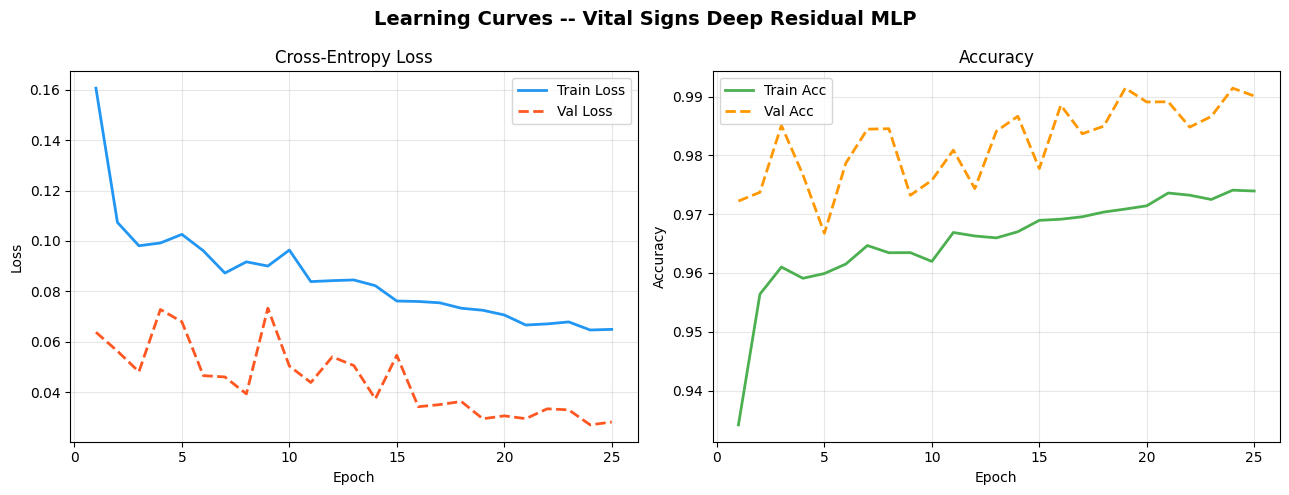

In [15]:
# ─── STEP 5 -- LEARNING CURVES ───────────────────────────────────────────────
hdr("STEP 5 -- LEARNING CURVES")

ep = range(1, len(hist["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Learning Curves -- Vital Signs Deep Residual MLP", fontsize=14, fontweight="bold")

axes[0].plot(ep, hist["train_loss"], label="Train Loss", color="#2196F3", lw=2)
axes[0].plot(ep, hist["val_loss"],   label="Val Loss",   color="#FF5722", lw=2, ls="--")
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, hist["train_acc"], label="Train Acc", color="#4CAF50", lw=2)
axes[1].plot(ep, hist["val_acc"],   label="Val Acc",   color="#FF9800", lw=2, ls="--")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


  STEP 6 -- EVALUATION METRICS

  Metric                            Value
  ----------------------------------------
  Accuracy                         0.9920
  F1-Score (Macro)                 0.9919
  F1-Score (Weighted)              0.9920
  Recall (Macro)                   0.9916
  Precision (Macro)                0.9923
  Cohen Kappa                      0.9879
  MCC                              0.9880
  ROC-AUC (OvR Macro)              0.9999

              precision    recall  f1-score   support

      Normal     0.9989    0.9761    0.9874      8131
    Abnormal     0.9779    0.9990    0.9883      8701
    Critical     1.0000    0.9998    0.9999      8701

    accuracy                         0.9920     25533
   macro avg     0.9923    0.9916    0.9919     25533
weighted avg     0.9921    0.9920    0.9920     25533



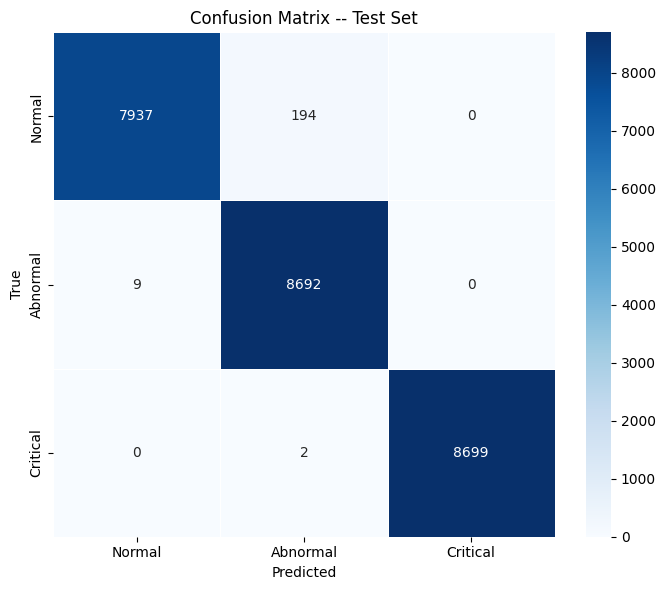

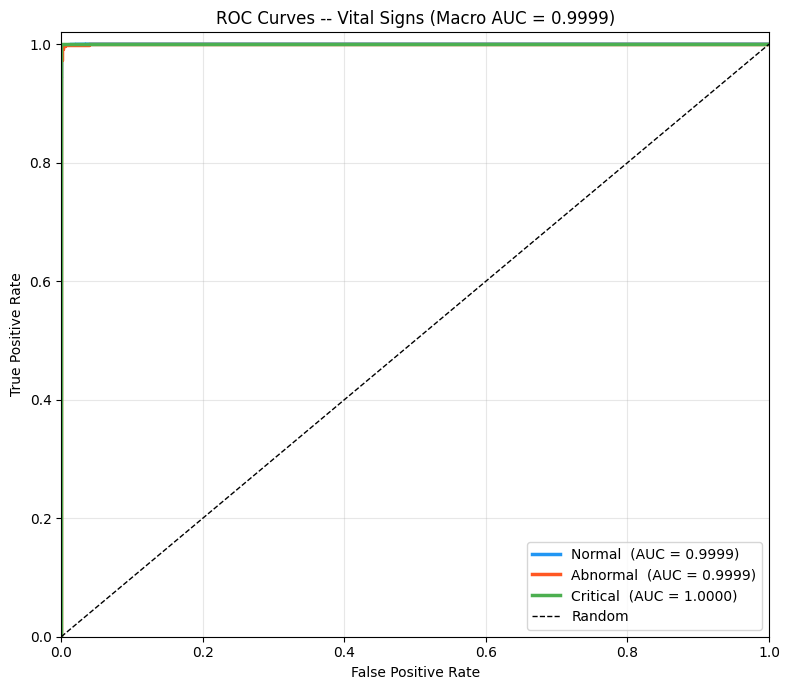

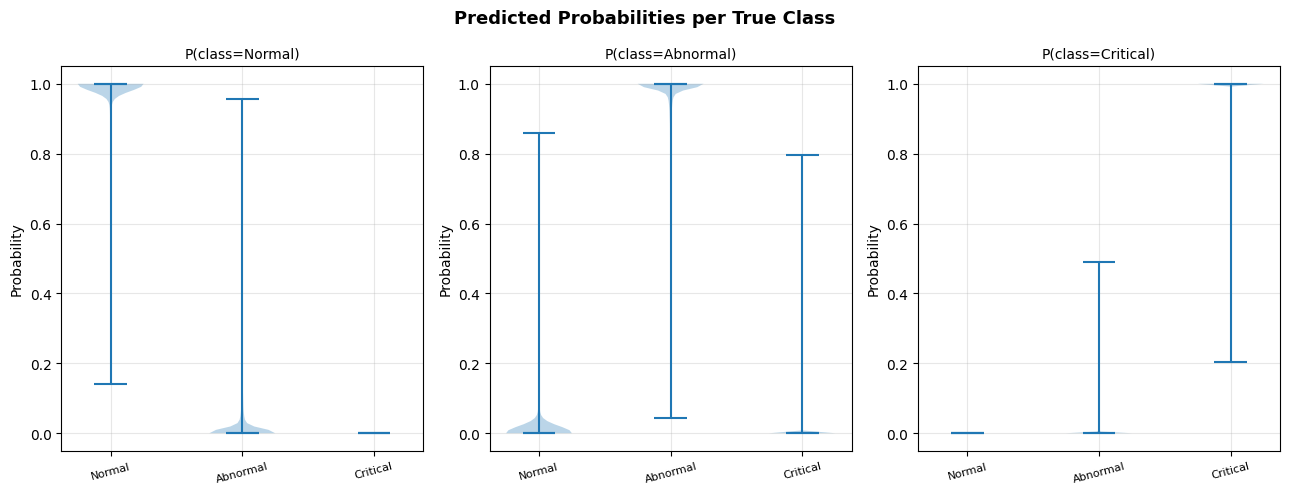

In [16]:
# ─── STEP 6 -- EVALUATION METRICS ────────────────────────────────────────────
hdr("STEP 6 -- EVALUATION METRICS")

model.eval()
all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        probs = F.softmax(model(Xb.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(np.argmax(probs, axis=1))
        all_true.append(yb.numpy())

y_prob = np.vstack(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)
y_bin  = label_binarize(y_true, classes=list(range(N_CLASSES)))

acc     = accuracy_score(y_true, y_pred)
f1_mac  = f1_score(y_true, y_pred, average="macro",    zero_division=0)
f1_wt   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
rec_mac = recall_score(y_true, y_pred, average="macro",    zero_division=0)
pre_mac = precision_score(y_true, y_pred, average="macro", zero_division=0)
kappa   = cohen_kappa_score(y_true, y_pred)
mcc     = matthews_corrcoef(y_true, y_pred)
roc_auc = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")

log(f"\n  {'Metric':<28} {'Value':>10}")
log(f"  {'-'*40}")
for name, val in [("Accuracy", acc), ("F1-Score (Macro)", f1_mac),
                  ("F1-Score (Weighted)", f1_wt), ("Recall (Macro)", rec_mac),
                  ("Precision (Macro)", pre_mac), ("Cohen Kappa", kappa),
                  ("MCC", mcc), ("ROC-AUC (OvR Macro)", roc_auc)]:
    log(f"  {name:<28} {val:>10.4f}")
log(f"\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4)}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, ax=ax)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix -- Test Set")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# ROC Curves
colors_roc = ["#2196F3", "#FF5722", "#4CAF50"]
fig, ax = plt.subplots(figsize=(8, 7))
for i, (cname, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    auc_i = skl_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{cname}  (AUC = {auc_i:.4f})")
ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax.set(xlim=[0,1], ylim=[0,1.02], xlabel="False Positive Rate",
       ylabel="True Positive Rate",
       title=f"ROC Curves -- Vital Signs (Macro AUC = {roc_auc:.4f})")
ax.legend(loc="lower right", fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Violin plots
fig, axes_v = plt.subplots(1, N_CLASSES, figsize=(13, 5))
fig.suptitle("Predicted Probabilities per True Class", fontsize=13, fontweight="bold")
for cls_i, (ax, cname) in enumerate(zip(axes_v, CLASS_NAMES)):
    data_cls = [y_prob[y_true == j, cls_i] for j in range(N_CLASSES)]
    ax.violinplot(data_cls, positions=range(N_CLASSES), showmedians=True)
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, fontsize=8, rotation=15)
    ax.set_title(f"P(class={cname})", fontsize=10)
    ax.set_ylabel("Probability"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_prob_violin.png"), dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 -- FLOPs CALCULATION
# ─────────────────────────────────────────────────────────────────────────────
hdr("STEP 7 -- FLOPs CALCULATION")

if THOP_OK:
    model.eval()
    dummy  = torch.randn(1, len(VITAL_FEATURES)).to(DEVICE)
    macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
    flops_total = int(macs) * 2
    log(f"  MACs (thop)      : {int(macs):,}")
    log(f"  FLOPs (2xMACs)   : {flops_total:,}")
    log(f"  FLOPs (MFLOPs)   : {flops_total/1e6:.4f}")
    log(f"  FLOPs (GFLOPs)   : {flops_total/1e9:.6f}")
else:
    flops_total = sum(2*m.in_features*m.out_features
                      for m in model.modules() if isinstance(m, nn.Linear))
    log(f"  FLOPs (manual)   : {flops_total:,}")
    log(f"  FLOPs (MFLOPs)   : {flops_total/1e6:.4f}")

log(f"  Total Parameters : {total_params:,}")


  STEP 7 -- FLOPs CALCULATION
  MACs (thop)      : 1,624,640
  FLOPs (2xMACs)   : 3,249,280
  FLOPs (MFLOPs)   : 3.2493
  FLOPs (GFLOPs)   : 0.003249
  Total Parameters : 1,622,275



  STEP 8 -- ENERGY CONSUMPTION & CARBON EMISSION
  Power (CPU+GPU)  : 65 W  (CPU=65W, GPU=0W)
  Carbon intensity : 0.233 kg CO2/kWh

  --- Training ---
  Duration         : 1917.68 s  (31.96 min)
  Energy           : 34.6247 Wh  (0.034625 kWh)
  CO2 emitted      : 8.0676 g  (0.008068 kg)

  --- Inference (test set: 25533 samples) ---
  Duration         : 0.8784 s
  Energy           : 0.015859 Wh
  CO2 emitted      : 0.003695 g

  --- Per Sample ---
  Energy / sample  : 0.6211 nWh
  CO2 / sample     : 0.1447 ug


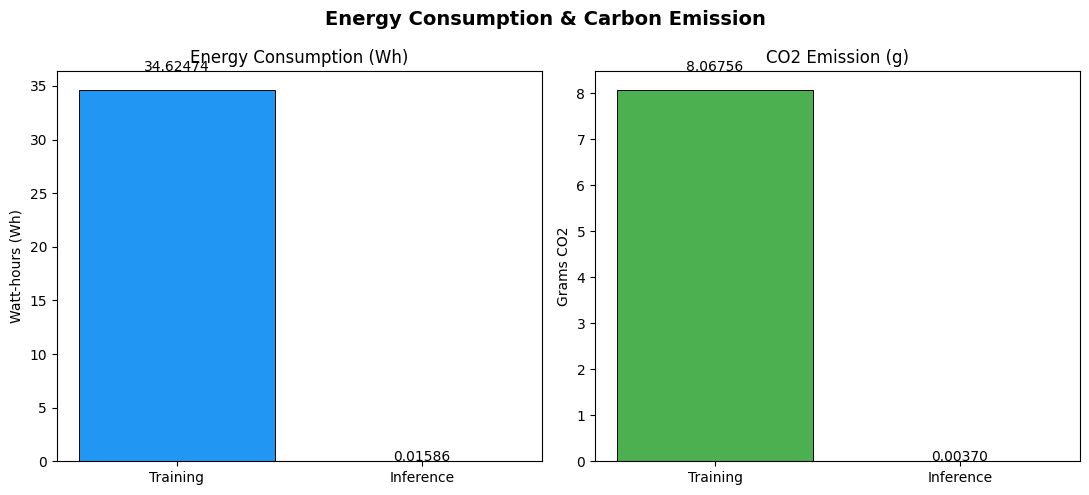

In [18]:
# ─── STEP 8 -- ENERGY CONSUMPTION & CARBON EMISSION ─────────────────────────
hdr("STEP 8 -- ENERGY CONSUMPTION & CARBON EMISSION")

total_power_w = CPU_WATTS + GPU_WATTS
train_kwh    = total_power_w * (train_time / 3600) / 1000
train_co2_kg = train_kwh * CARBON_KG_PER_KWH
train_co2_g  = train_co2_kg * 1000

infer_start = time.time()
model.eval()
with torch.no_grad():
    for Xb, _ in test_loader:
        _ = model(Xb.to(DEVICE))
infer_time  = time.time() - infer_start
infer_kwh   = total_power_w * (infer_time / 3600) / 1000
infer_co2_g = infer_kwh * CARBON_KG_PER_KWH * 1000
n_test      = len(y_te_raw)

log(f"  Power (CPU+GPU)  : {total_power_w} W  (CPU={CPU_WATTS}W, GPU={GPU_WATTS}W)")
log(f"  Carbon intensity : {CARBON_KG_PER_KWH} kg CO2/kWh")
log(f"\n  --- Training ---")
log(f"  Duration         : {train_time:.2f} s  ({train_time/60:.2f} min)")
log(f"  Energy           : {train_kwh*1000:.4f} Wh  ({train_kwh:.6f} kWh)")
log(f"  CO2 emitted      : {train_co2_g:.4f} g  ({train_co2_kg:.6f} kg)")
log(f"\n  --- Inference (test set: {n_test} samples) ---")
log(f"  Duration         : {infer_time:.4f} s")
log(f"  Energy           : {infer_kwh*1000:.6f} Wh")
log(f"  CO2 emitted      : {infer_co2_g:.6f} g")
log(f"\n  --- Per Sample ---")
log(f"  Energy / sample  : {infer_kwh/n_test*1e9:.4f} nWh")
log(f"  CO2 / sample     : {infer_co2_g/n_test*1e6:.4f} ug")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Energy Consumption & Carbon Emission", fontsize=14, fontweight="bold")
cats = ["Training", "Inference"]
e_v  = [train_kwh*1000, infer_kwh*1000]
c_v  = [train_co2_g, infer_co2_g]

for ax, vals, lbl, clrs in [
    (ax1, e_v, "Watt-hours (Wh)", ["#2196F3","#FF9800"]),
    (ax2, c_v, "Grams CO2",       ["#4CAF50","#F44336"]),
]:
    ax.bar(cats, vals, color=clrs, edgecolor="black", linewidth=0.7)
    ax.set_ylabel(lbl)
    for i, v in enumerate(vals):
        ax.text(i, v*1.05, f"{v:.5f}", ha="center", fontsize=10)

ax1.set_title("Energy Consumption (Wh)")
ax2.set_title("CO2 Emission (g)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_energy_carbon.png"), dpi=150, bbox_inches="tight")
plt.show()


  STEP 9 -- SUMMARY DASHBOARD


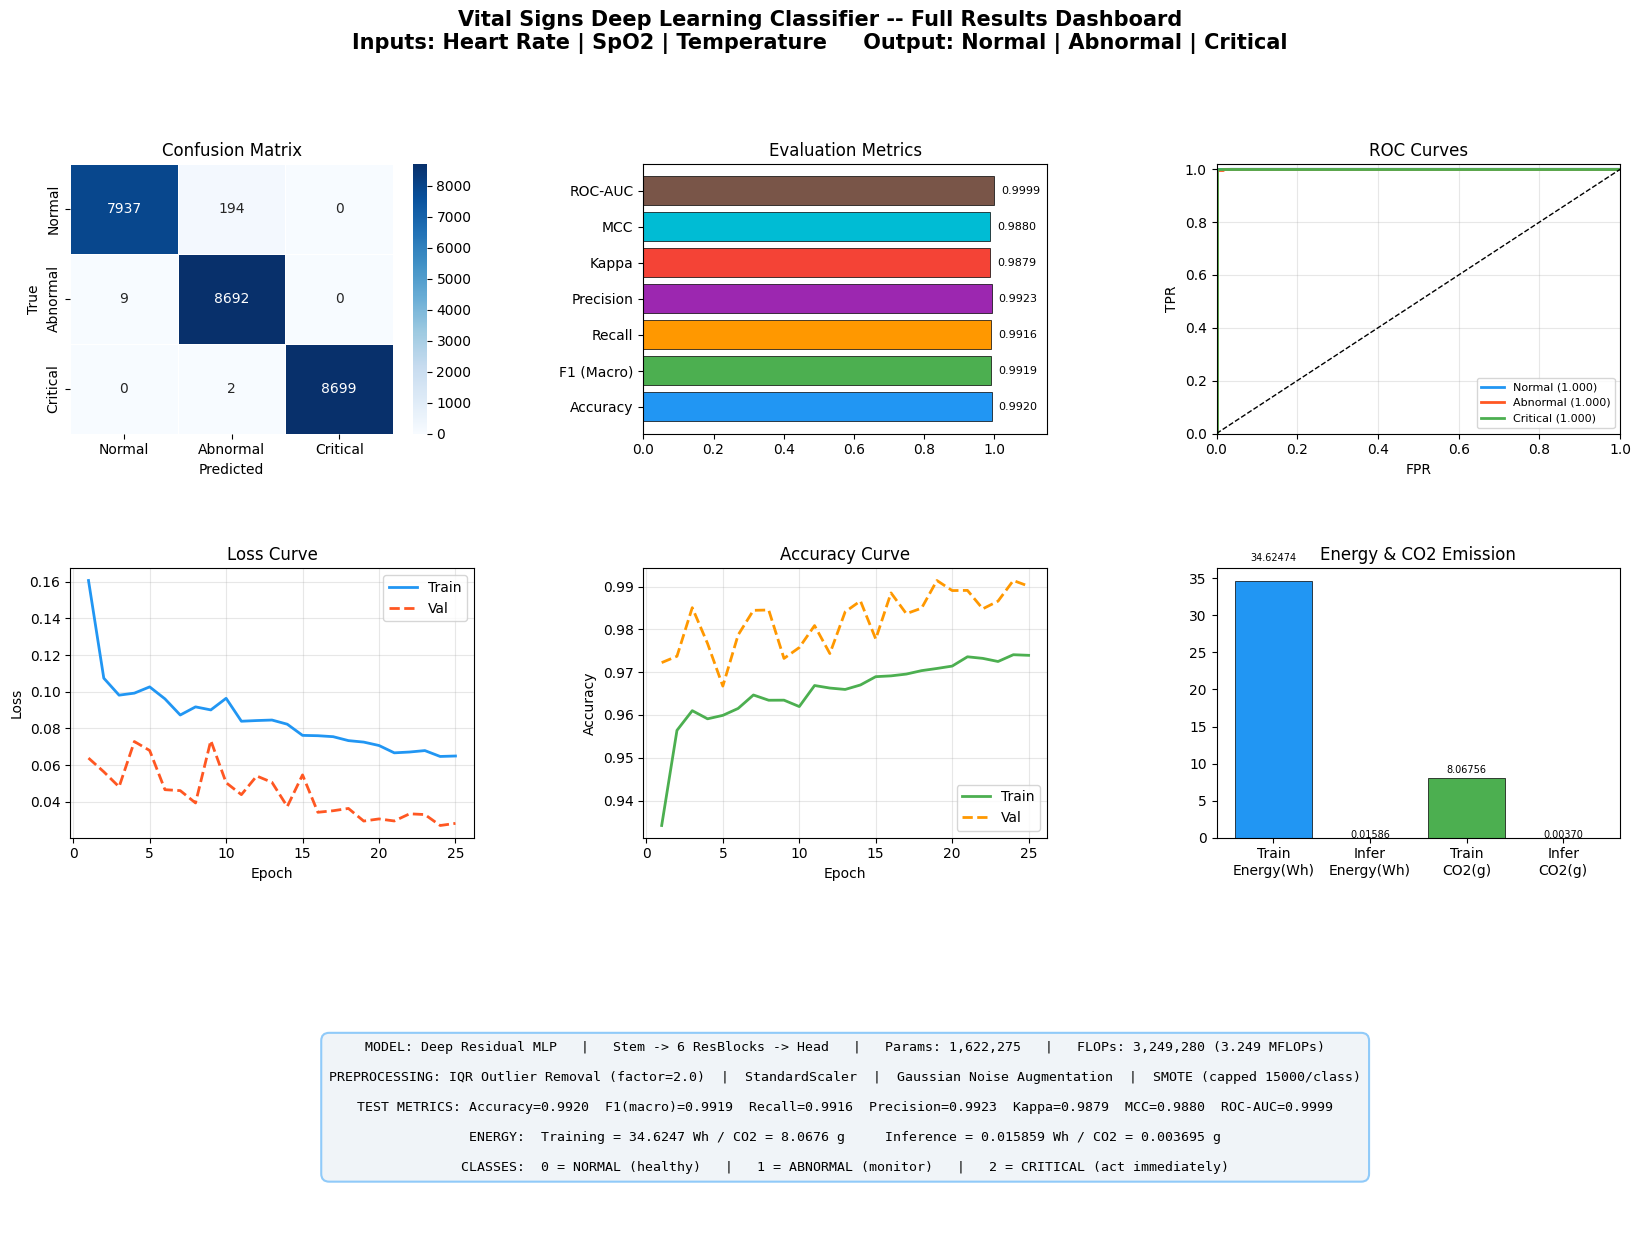

  Dashboard saved -> c:\Users\HP\Downloads\AI XGBoost V3\AI XGBoost V3\selected topics\outputs\06_summary_dashboard.png


In [19]:
# ─── STEP 9 -- SUMMARY DASHBOARD (6-panel) ───────────────────────────────────
hdr("STEP 9 -- SUMMARY DASHBOARD")

fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    "Vital Signs Deep Learning Classifier -- Full Results Dashboard\n"
    "Inputs: Heart Rate | SpO2 | Temperature     Output: Normal | Abnormal | Critical",
    fontsize=15, fontweight="bold", y=0.99,
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.42)

# Confusion matrix
ax = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, ax=ax)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")

# Metrics bar
ax = fig.add_subplot(gs[0, 1])
m_n = ["Accuracy","F1 (Macro)","Recall","Precision","Kappa","MCC","ROC-AUC"]
m_v = [acc, f1_mac, rec_mac, pre_mac, kappa, mcc, roc_auc]
m_c = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4","#795548"]
bars = ax.barh(m_n, m_v, color=m_c, edgecolor="black", linewidth=0.5)
ax.set_xlim(0, 1.15); ax.set_title("Evaluation Metrics")
for bar, val in zip(bars, m_v):
    ax.text(val+0.02, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=8)

# ROC curves
ax = fig.add_subplot(gs[0, 2])
for i, (cname, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cname} ({skl_auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set(xlabel="FPR", ylabel="TPR", title="ROC Curves", xlim=[0,1], ylim=[0,1.02])
ax.legend(loc="lower right", fontsize=8); ax.grid(True, alpha=0.3)

# Loss curve
ax = fig.add_subplot(gs[1, 0])
ax.plot(ep, hist["train_loss"], label="Train", color="#2196F3", lw=2)
ax.plot(ep, hist["val_loss"],   label="Val",   color="#FF5722", lw=2, ls="--")
ax.set(title="Loss Curve", xlabel="Epoch", ylabel="Loss"); ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy curve
ax = fig.add_subplot(gs[1, 1])
ax.plot(ep, hist["train_acc"], label="Train", color="#4CAF50", lw=2)
ax.plot(ep, hist["val_acc"],   label="Val",   color="#FF9800", lw=2, ls="--")
ax.set(title="Accuracy Curve", xlabel="Epoch", ylabel="Accuracy"); ax.legend(); ax.grid(True, alpha=0.3)

# Energy & Carbon
ax = fig.add_subplot(gs[1, 2])
eco_l = ["Train\nEnergy(Wh)","Infer\nEnergy(Wh)","Train\nCO2(g)","Infer\nCO2(g)"]
eco_v = [train_kwh*1000, infer_kwh*1000, train_co2_g, infer_co2_g]
eco_c = ["#2196F3","#03A9F4","#4CAF50","#8BC34A"]
ax.bar(eco_l, eco_v, color=eco_c, edgecolor="black", linewidth=0.5)
ax.set_title("Energy & CO2 Emission")
for i, v in enumerate(eco_v):
    ax.text(i, v*1.08, f"{v:.5f}", ha="center", fontsize=7)

# Text summary
ax_txt = fig.add_subplot(gs[2, :])
ax_txt.axis("off")
summary_text = (
    f"MODEL: Deep Residual MLP   |   Stem -> 6 ResBlocks -> Head   |   "
    f"Params: {total_params:,}   |   FLOPs: {flops_total:,} ({flops_total/1e6:.3f} MFLOPs)\n\n"
    f"PREPROCESSING: IQR Outlier Removal (factor=2.0)  |  StandardScaler  |  "
    f"Gaussian Noise Augmentation  |  SMOTE (capped {SMOTE_CAP}/class)\n\n"
    f"TEST METRICS: Accuracy={acc:.4f}  F1(macro)={f1_mac:.4f}  Recall={rec_mac:.4f}  "
    f"Precision={pre_mac:.4f}  Kappa={kappa:.4f}  MCC={mcc:.4f}  ROC-AUC={roc_auc:.4f}\n\n"
    f"ENERGY:  Training = {train_kwh*1000:.4f} Wh / CO2 = {train_co2_g:.4f} g     "
    f"Inference = {infer_kwh*1000:.6f} Wh / CO2 = {infer_co2_g:.6f} g\n\n"
    f"CLASSES:  0 = NORMAL (healthy)   |   1 = ABNORMAL (monitor)   |   2 = CRITICAL (act immediately)"
)
ax_txt.text(0.5, 0.5, summary_text, transform=ax_txt.transAxes,
            ha="center", va="center", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#f0f4f8", edgecolor="#90CAF9", lw=1.5),
            fontfamily="monospace")

plt.savefig(os.path.join(OUTPUT_DIR, "06_summary_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()
log(f"  Dashboard saved -> {os.path.join(OUTPUT_DIR, '06_summary_dashboard.png')}")

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 10 -- SAVE MODEL & LOG
# ─────────────────────────────────────────────────────────────────────────────
hdr("STEP 10 -- SAVING OUTPUTS")

torch.save({
    "model_state":      best_state,
    "scaler_mean":      scaler.mean_.tolist(),
    "scaler_std":       scaler.scale_.tolist(),
    "classes":          CLASS_NAMES,
    "architecture":     "DeepResidualMLP_6blocks",
    "metrics": {
        "accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wt,
        "recall": rec_mac, "precision": pre_mac,
        "kappa": kappa, "mcc": mcc, "roc_auc": roc_auc,
        "flops": flops_total, "params": total_params,
        "train_energy_kwh": train_kwh, "train_co2_kg": train_co2_kg,
        "infer_energy_kwh": infer_kwh, "infer_co2_g": infer_co2_g,
    }
}, os.path.join(OUTPUT_DIR, "vitalsigns_dl_model.pt"))
log(f"  Model -> {os.path.join(OUTPUT_DIR, 'vitalsigns_dl_model.pt')}")

log("""
  +----------------------------------------------------------+
  |         CLASSIFICATION RESULT GUIDE                     |
  +----------------------------------------------------------+
  |  Class 0 -> NORMAL   : Vital signs within healthy range |
  |  Class 1 -> ABNORMAL : Outside normal range -- monitor  |
  |  Class 2 -> CRITICAL : Dangerous levels -- act NOW      |
  +----------------------------------------------------------+
""")

log_path = os.path.join(OUTPUT_DIR, "results_log.txt")
with open(log_path, "w", encoding="utf-8") as f:
    f.write("\n".join(_LOG))
log(f"  Log  -> {log_path}")
log("\n  [OK] PIPELINE COMPLETE")
log(f"  Outputs -> {OUTPUT_DIR}")



  STEP 10 -- SAVING OUTPUTS
  Model -> c:\Users\HP\Downloads\AI XGBoost V3\AI XGBoost V3\selected topics\outputs\vitalsigns_dl_model.pt

  +----------------------------------------------------------+
  |         CLASSIFICATION RESULT GUIDE                     |
  +----------------------------------------------------------+
  |  Class 0 -> NORMAL   : Vital signs within healthy range |
  |  Class 1 -> ABNORMAL : Outside normal range -- monitor  |
  |  Class 2 -> CRITICAL : Dangerous levels -- act NOW      |
  +----------------------------------------------------------+

  Log  -> c:\Users\HP\Downloads\AI XGBoost V3\AI XGBoost V3\selected topics\outputs\results_log.txt

  [OK] PIPELINE COMPLETE
  Outputs -> c:\Users\HP\Downloads\AI XGBoost V3\AI XGBoost V3\selected topics\outputs



  STEP 11 -- LIVE PREDICTION TEST

  Case                     HR  SpO2  Temp  Prediction   Conf  [N%  / Ab% / Cr%]
  --------------------------------------------------------------------------------
  Healthy Adult            72    98  36.6  [OK] Normal     100.0%  [100.0 /  0.0 /  0.0]
  Mild Fever               88    95  38.5  [WARN] Abnormal    94.3%  [ 0.0 / 94.3 /  5.7]
  Bradycardia              42    97  36.8  [ALERT] Critical   100.0%  [ 0.0 /  0.0 / 100.0]
  Hypoxia                  95    88  37.0  [ALERT] Critical   100.0%  [ 0.0 /  0.0 / 100.0]
  Tachycardia + Fever     130    92  39.8  [ALERT] Critical   100.0%  [ 0.0 /  0.0 / 100.0]
  Critical Shock           35    78  34.0  [ALERT] Critical   100.0%  [ 0.0 /  0.0 / 100.0]
  High HR episode         115    96  37.2  [WARN] Abnormal    99.9%  [ 0.0 / 99.9 /  0.1]
  Athlete resting          48    99  36.4  [ALERT] Critical    97.7%  [ 0.0 /  2.2 / 97.7]

  Batch test on 500 random test samples:
    Normal      :  97.52%  (161

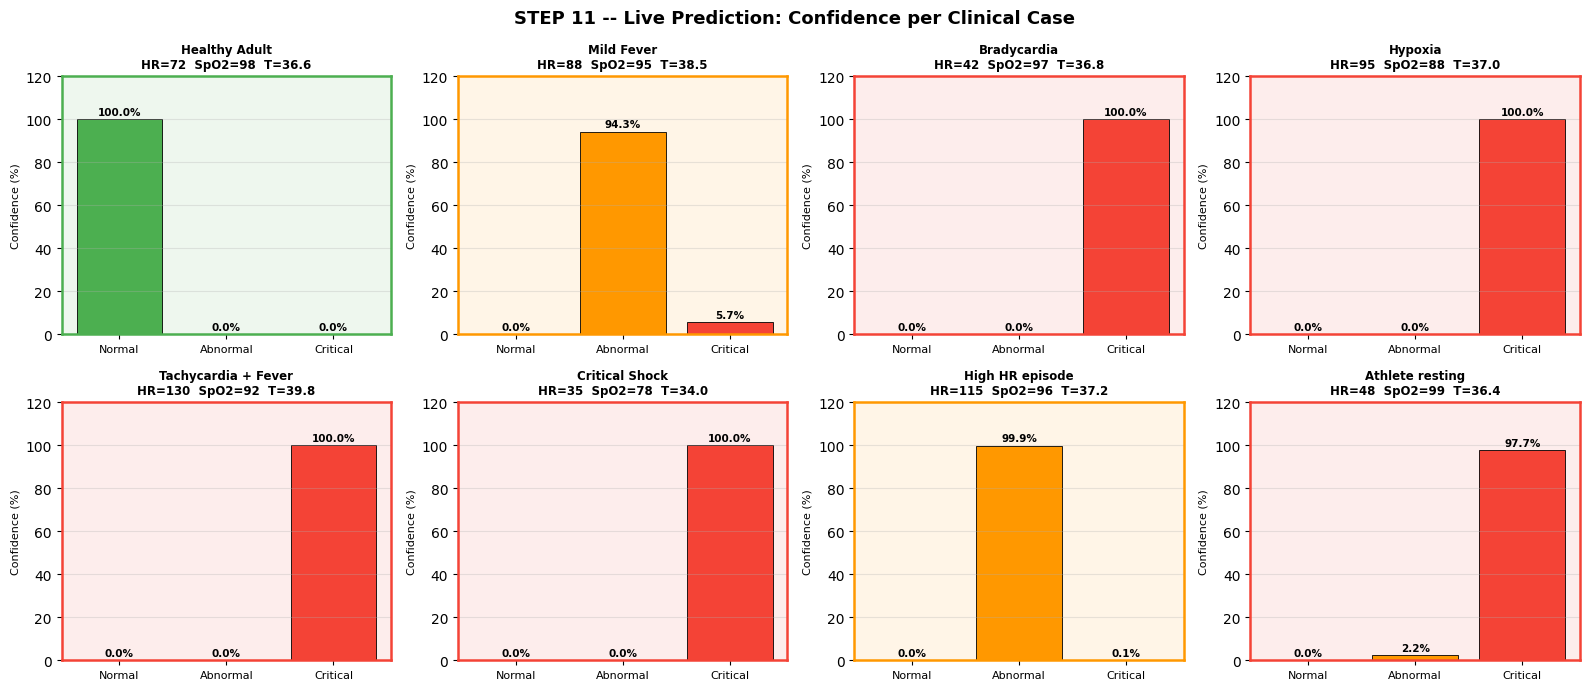

  Saved -> c:\Users\HP\Downloads\AI XGBoost V3\AI XGBoost V3\selected topics\outputs\07_live_predictions.png



  Interactive widget ready -- adjust sliders and click Predict.


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 11 -- LIVE PREDICTION TEST
# ─────────────────────────────────────────────────────────────────────────────
hdr("STEP 11 -- LIVE PREDICTION TEST")

RISK_COLORS = {"Normal": "#4CAF50", "Abnormal": "#FF9800", "Critical": "#F44336"}
RISK_TAG    = {"Normal": "OK",      "Abnormal": "WARN",    "Critical": "ALERT"}

def predict_single(heart_rate, spo2, temperature):
    x_raw    = np.array([[heart_rate, spo2, temperature]], dtype=np.float32)
    x_scaled = scaler.transform(x_raw)
    tensor   = torch.FloatTensor(x_scaled).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1).cpu().numpy()[0]
    cls_idx = int(np.argmax(probs))
    return cls_idx, CLASS_NAMES[cls_idx], probs

# ── 1. Predefined clinical test cases ────────────────────────────────────────
test_cases = [
    ("Healthy Adult",        72,  98, 36.6),
    ("Mild Fever",           88,  95, 38.5),
    ("Bradycardia",          42,  97, 36.8),
    ("Hypoxia",              95,  88, 37.0),
    ("Tachycardia + Fever", 130,  92, 39.8),
    ("Critical Shock",       35,  78, 34.0),
    ("High HR episode",     115,  96, 37.2),
    ("Athlete resting",      48,  99, 36.4),
]

log(f"\n  {'Case':<22} {'HR':>4} {'SpO2':>5} {'Temp':>5}  {'Prediction':<10} {'Conf':>6}  [N%  / Ab% / Cr%]")
log(f"  {'-'*80}")
for name, hr, sp, tp in test_cases:
    cls_idx, label, probs = predict_single(hr, sp, tp)
    conf = probs[cls_idx] * 100
    log(f"  {name:<22} {hr:>4}  {sp:>4}  {tp:>4.1f}  "
        f"[{RISK_TAG[label]}] {label:<9}  {conf:>5.1f}%  "
        f"[{probs[0]*100:4.1f} / {probs[1]*100:4.1f} / {probs[2]*100:4.1f}]")

# ── 2. Random batch test on 500 test samples ──────────────────────────────────
n_sample = min(500, len(y_te_raw))
rng_idx  = np.random.choice(len(y_te_raw), n_sample, replace=False)
X_s, y_s = X_te[rng_idx], y_te_raw[rng_idx]
model.eval()
with torch.no_grad():
    probs_s = F.softmax(model(torch.FloatTensor(X_s).to(DEVICE)), dim=1).cpu().numpy()
preds_s = np.argmax(probs_s, axis=1)

log(f"\n  Batch test on {n_sample} random test samples:")
for c in range(N_CLASSES):
    mask = y_s == c
    if mask.sum() == 0:
        continue
    acc_c = (preds_s[mask] == y_s[mask]).mean()
    log(f"    {CLASS_NAMES[c]:<12}: {acc_c*100:6.2f}%  ({mask.sum()} samples)")
log(f"    {'Overall':<12}: {(preds_s == y_s).mean()*100:6.2f}%")

# ── 3. Confidence bar chart for each clinical case ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("STEP 11 -- Live Prediction: Confidence per Clinical Case",
             fontsize=13, fontweight="bold")
axes = axes.flatten()
bar_colors = ["#4CAF50", "#FF9800", "#F44336"]

for ax, (name, hr, sp, tp) in zip(axes, test_cases):
    cls_idx, label, probs = predict_single(hr, sp, tp)
    bars = ax.bar(CLASS_NAMES, probs * 100, color=bar_colors,
                  edgecolor="black", linewidth=0.6)
    ax.set_ylim(0, 120)
    ax.set_title(f"{name}\nHR={hr}  SpO2={sp}  T={tp}", fontsize=8.5, fontweight="bold")
    ax.set_ylabel("Confidence (%)", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for bar, val in zip(bars, probs * 100):
        ax.text(bar.get_x() + bar.get_width()/2, val + 2,
                f"{val:.1f}%", ha="center", fontsize=7.5, fontweight="bold")
    color = RISK_COLORS[label]
    ax.set_facecolor(color + "18")
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(1.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_live_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
log(f"  Saved -> {os.path.join(OUTPUT_DIR, '07_live_predictions.png')}")

# ── 4. Interactive widget ─────────────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    hr_sl   = widgets.FloatSlider(value=75,   min=20,  max=200, step=1,   description="Heart Rate:")
    sp_sl   = widgets.FloatSlider(value=98,   min=50,  max=100, step=0.5, description="SpO2 (%):")
    tp_sl   = widgets.FloatSlider(value=36.6, min=32,  max=42,  step=0.1, description="Temp (C):")
    btn     = widgets.Button(description="Predict", button_style="primary")
    out_w   = widgets.Output()

    def on_click(b):
        with out_w:
            clear_output(wait=True)
            cls_idx, label, probs = predict_single(hr_sl.value, sp_sl.value, tp_sl.value)
            conf = probs[cls_idx] * 100
            print(f"\n  Input  : HR={hr_sl.value:.0f} bpm  SpO2={sp_sl.value:.1f}%  Temp={tp_sl.value:.1f}C")
            print(f"  Result : [{RISK_TAG[label]}] {label}  ({conf:.1f}% confidence)")
            print(f"  Probs  : Normal={probs[0]*100:.1f}%  Abnormal={probs[1]*100:.1f}%  Critical={probs[2]*100:.1f}%")

    btn.on_click(on_click)
    display(widgets.VBox([hr_sl, sp_sl, tp_sl, btn, out_w]))
    log("\n  Interactive widget ready -- adjust sliders and click Predict.")
except Exception as e:
    log(f"\n  [INFO] Widget not available ({e}) -- use predict_single(hr, spo2, temp) directly.")
    log("  Example: predict_single(72, 98, 36.6)")
